<a href="https://colab.research.google.com/github/DataBifrost/Bits_pilani/blob/main/Copy_of_2025AG05392_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# CELL 1 — ENVIRONMENT SETUP & IMPORTS
# ============================================================
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))


TensorFlow version : 2.19.0
Keras version      : 3.13.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2 — DATASET SELECTION & METADATA
# ============================================================
# This template uses Cats vs Dogs from TensorFlow Datasets.
# It satisfies the 500 images-per-class minimum with no local files.
# Change DATASET_CHOICE if you prefer another allowed dataset.

import tensorflow_datasets as tfds

# ── 1.1  Required metadata ──────────────────────────────────
dataset_name        = "Cats vs Dogs"
dataset_source      = "tensorflow_datasets (microsoft/catsvsdogs)"
n_classes           = 2
image_shape         = [224, 224, 3]
problem_type        = "classification"
train_test_ratio    = "90/10"

# Primary metric choice — edit as appropriate for your dataset
primary_metric       = "accuracy"
metric_justification = (
    "Cats vs Dogs is a balanced binary dataset with roughly equal class "
    "distribution, so accuracy is an unbiased summary metric and is the "
    "standard primary measure for this benchmark."
)

# ── 1.2  Load dataset ───────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Load ~23,000 labelled images; keep 10 % for test
(raw_train, raw_test), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

train_ds = (raw_train
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds  = (raw_test
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

# Count samples
train_samples = int(info.splits['train'].num_examples * 0.9)
test_samples  = int(info.splits['train'].num_examples * 0.1)
n_samples     = train_samples + test_samples
samples_per_class = f"min: ~{n_samples//n_classes - 200}, max: ~{n_samples//n_classes + 200}, avg: ~{n_samples//n_classes}"

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"Dataset            : {dataset_name}")
print(f"Source             : {dataset_source}")
print(f"Total Samples      : {n_samples}")
print(f"Number of Classes  : {n_classes}  ({['Cat', 'Dog']})")
print(f"Samples per Class  : {samples_per_class}")
print(f"Image Shape        : {image_shape}")
print(f"Train/Test Split   : {train_test_ratio}")
print(f"Training Samples   : {train_samples}")
print(f"Test Samples       : {test_samples}")
print(f"Primary Metric     : {primary_metric}")
print(f"Justification      : {metric_justification}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UNYXWP_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
DATASET INFORMATION
Dataset            : Cats vs Dogs
Source             : tensorflow_datasets (microsoft/catsvsdogs)
Total Samples      : 23261
Number of Classes  : 2  (['Cat', 'Dog'])
Samples per Class  : min: ~11430, max: ~11830, avg: ~11630
Image Shape        : [224, 224, 3]
Train/Test Split   : 90/10
Training Samples   : 20935
Test Samples       : 2326
Primary Metric     : accuracy
Justification      : Cats vs Dogs is a balanced binary dataset with roughly equal class distribution, so accuracy is an unbiased summary metric and is the standard primary measure for this benchmark.


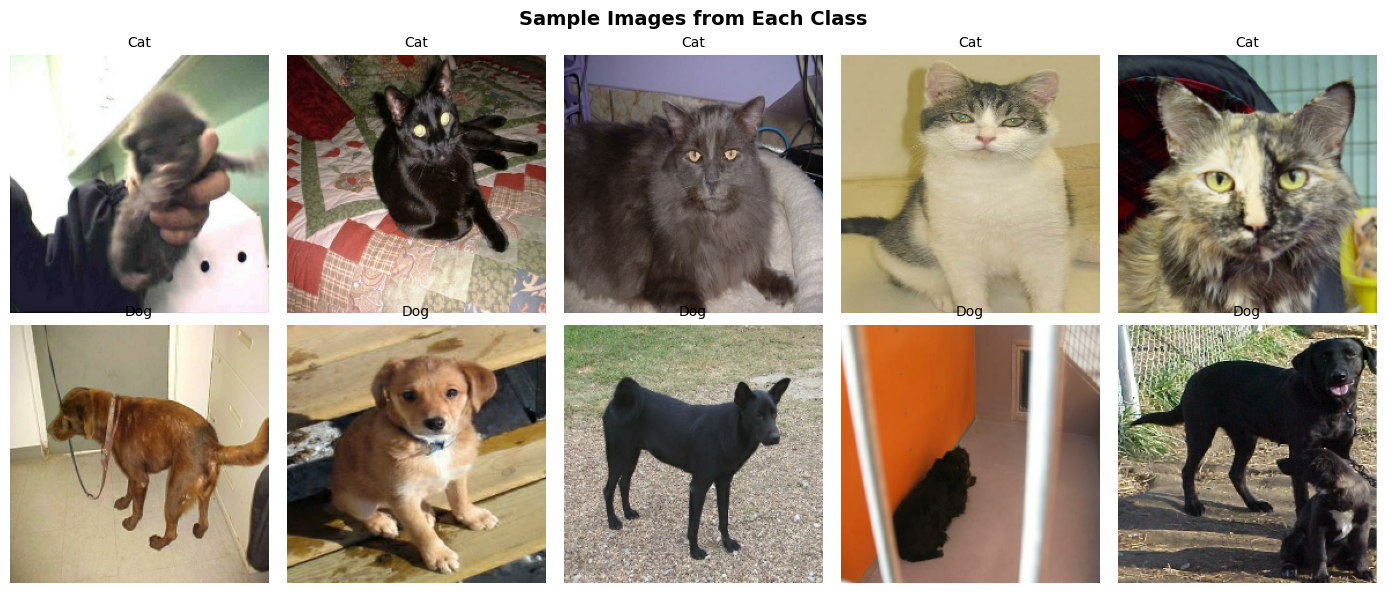

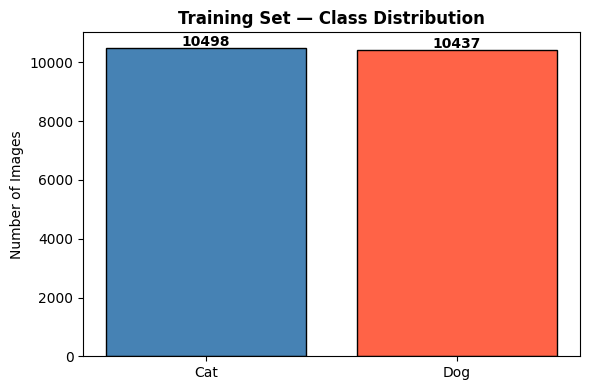

Cat images  : 10498
Dog images  : 10437
Balance ratio: 0.994  (1.0 = perfectly balanced)


In [3]:
# ============================================================
# CELL 3 — EXPLORATORY DATA ANALYSIS
# ============================================================
CLASS_NAMES = ['Cat', 'Dog']

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Images from Each Class", fontsize=14, fontweight='bold')

sample_batch = next(iter(train_ds))
images, labels = sample_batch[0].numpy(), sample_batch[1].numpy()

cats = [i for i, l in enumerate(labels) if l == 0][:5]
dogs = [i for i, l in enumerate(labels) if l == 1][:5]

for col, idx in enumerate(cats):
    axes[0, col].imshow(images[idx])
    axes[0, col].set_title("Cat", fontsize=10)
    axes[0, col].axis('off')

for col, idx in enumerate(dogs):
    axes[1, col].imshow(images[idx])
    axes[1, col].set_title("Dog", fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

# Class distribution
cat_count = sum(1 for _, lbl in raw_train if lbl.numpy() == 0)
dog_count = train_samples - cat_count

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(CLASS_NAMES, [cat_count, dog_count], color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title("Training Set — Class Distribution", fontweight='bold')
ax.set_ylabel("Number of Images")
for i, v in enumerate([cat_count, dog_count]):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Cat images  : {cat_count}")
print(f"Dog images  : {dog_count}")
print(f"Balance ratio: {min(cat_count,dog_count)/max(cat_count,dog_count):.3f}  (1.0 = perfectly balanced)")


In [4]:
# ============================================================
# CELL 4 — CUSTOM CNN ARCHITECTURE
# ============================================================

def build_custom_cnn(input_shape=(224, 224, 3), n_classes=2):
    """
    Custom CNN with:
      - 3 × Conv2D blocks (Conv → BN → ReLU → MaxPool)
      - GlobalAveragePooling2D  ← MANDATORY (no Flatten/Dense)
      - Dropout for regularisation
      - Softmax output
    """
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # ── Global Average Pooling (MANDATORY — replaces Flatten+Dense) ──
    x = layers.GlobalAveragePooling2D()(x)   # shape: (batch, 128)

    x = layers.Dropout(0.4)(x)

    # Output
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="CustomCNN")
    return model


custom_cnn = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=n_classes)

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()
print(f"\nTotal parameters    : {custom_cnn.count_params():,}")
print(f"Trainable parameters: {sum(tf.size(v).numpy() for v in custom_cnn.trainable_variables):,}")


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,402 (368.76 KB)

 Trainable params: 93,954 (367.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters    : 94,402
Trainable parameters: 93,954


In [2]:
# ============================================================
# CELL 5 — TRAIN CUSTOM CNN
# ============================================================
EPOCHS_CUSTOM = 20

print("=" * 70)
print("CUSTOM CNN TRAINING")
print("=" * 70)

custom_cnn_start_time = time.time()

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_custom = custom_cnn.fit(
    train_ds,
    epochs=EPOCHS_CUSTOM,
    validation_data=test_ds,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = history_custom.history['loss'][0]
custom_cnn_final_loss   = history_custom.history['loss'][-1]
loss_reduction_custom   = ((custom_cnn_initial_loss - custom_cnn_final_loss)
                           / custom_cnn_initial_loss) * 100

print(f"\nTraining time  : {custom_cnn_training_time:.1f}s")
print(f"Initial loss   : {custom_cnn_initial_loss:.4f}")
print(f"Final loss     : {custom_cnn_final_loss:.4f}")
print(f"Loss reduction : {loss_reduction_custom:.1f}%")


CUSTOM CNN TRAINING


NameError: name 'time' is not defined

In [1]:
# ============================================================
# CELL 6 — EVALUATE CUSTOM CNN
# ============================================================
print("=" * 70)
print("CUSTOM CNN EVALUATION")
print("=" * 70)

# Collect predictions over the entire test set
y_true_custom, y_pred_custom = [], []
for images, labels in test_ds:
    preds = custom_cnn.predict(images, verbose=0)
    y_pred_custom.extend(np.argmax(preds, axis=1))
    y_true_custom.extend(labels.numpy())

y_true_custom = np.array(y_true_custom)
y_pred_custom = np.array(y_pred_custom)

# ── 4 required metrics ──────────────────────────────────────
custom_cnn_accuracy  = accuracy_score(y_true_custom, y_pred_custom)
custom_cnn_precision = precision_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)
custom_cnn_recall    = recall_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)
custom_cnn_f1        = f1_score(y_true_custom, y_pred_custom, average='macro', zero_division=0)

print(f"Accuracy  : {custom_cnn_accuracy:.4f}")
print(f"Precision : {custom_cnn_precision:.4f}")
print(f"Recall    : {custom_cnn_recall:.4f}")
print(f"F1-Score  : {custom_cnn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_custom, y_pred_custom, target_names=CLASS_NAMES))

# Confusion matrix
cm_custom = confusion_matrix(y_true_custom, y_pred_custom)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Custom CNN — Confusion Matrix", fontweight='bold')
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_custom.history['loss'], label='Train')
axes[0].plot(history_custom.history['val_loss'], label='Val')
axes[0].set_title("Custom CNN — Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history_custom.history['accuracy'], label='Train')
axes[1].plot(history_custom.history['val_accuracy'], label='Val')
axes[1].set_title("Custom CNN — Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()


CUSTOM CNN EVALUATION


NameError: name 'test_ds' is not defined